# Análisis Exploratorio de Datos (EDA) - TuboCast

## Significado de la unidad de observación
En este dataset, la unidad de observación principal es **un video de YouTube en un momento temporal específico ($t$)**, acompañado de una muestra de sus comentarios. Esto nos permite evaluar el rendimiento inicial (vistas, likes) cruzado con la interacción textual de los usuarios.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
df_stats = pd.read_csv('../data/raw/video_stats_sample.csv')
df_comments = pd.read_csv('../data/raw/comentarios_sample.csv')

# Tamaño, columnas y tipos de datos
print("--- ESTADÍSTICAS DEL VIDEO ---")
print(f"Tamaño: {df_stats.shape}")
df_stats.info()

print("\n--- COMENTARIOS ---")
print(f"Tamaño: {df_comments.shape}")
df_comments.info()

--- ESTADÍSTICAS DEL VIDEO ---
Tamaño: (1, 5)
<class 'pandas.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   video_id     1 non-null      str  
 1   titulo       1 non-null      str  
 2   vistas       1 non-null      int64
 3   likes        1 non-null      int64
 4   comentarios  1 non-null      int64
dtypes: int64(3), str(2)
memory usage: 172.0 bytes

--- COMENTARIOS ---
Tamaño: (50, 2)
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   texto             50 non-null     str  
 1   likes_comentario  50 non-null     int64
dtypes: int64(1), str(1)
memory usage: 932.0 bytes


In [2]:
# Valores faltantes, duplicados y valores atípicos relevantes
print("Faltantes en stats:\n", df_stats.isnull().sum())
print("\nDuplicados en comentarios:", df_comments.duplicated().sum())

# Mostrar estadísticas descriptivas (para identificar atípicos)
display(df_comments.describe())

Faltantes en stats:
 video_id       0
titulo         0
vistas         0
likes          0
comentarios    0
dtype: int64

Duplicados en comentarios: 1


,likes_comentario
count,50.000000
mean,6313.080000
std,44636.464815
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,315628.000000


In [3]:
# Valores faltantes, duplicados y valores atípicos relevantes
print("Faltantes en stats:\n", df_stats.isnull().sum())
print("\nDuplicados en comentarios:", df_comments.duplicated().sum())

# Mostrar estadísticas descriptivas (para identificar atípicos)
display(df_comments.describe())

Faltantes en stats:
 video_id       0
titulo         0
vistas         0
likes          0
comentarios    0
dtype: int64

Duplicados en comentarios: 1


,likes_comentario
count,50.000000
mean,6313.080000
std,44636.464815
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,315628.000000


### Interpretación de calidad de datos
A partir de esta muestra inicial, identificamos tres comportamientos clave en los datos:

* **Completitud:** No hay valores nulos (`NaN`) en ninguna de las dos tablas. La API entregó los metadatos y el texto de manera íntegra para esta muestra.
* **Duplicados:** Se detectó 1 registro duplicado en la tabla de comentarios. Esto es un comportamiento normal en YouTube (usuarios haciendo *spam* o publicando el mismo texto varias veces) y deberá eliminarse en el notebook de preparación de datos.
* **Valores atípicos (Outliers) y asimetría:** La variable `likes_comentario` presenta una asimetría extrema hacia la derecha. El 75% de los comentarios tienen 1 *like* o menos (con una mediana de 0), pero existe un valor máximo atípico de 315,628 *likes*. Esto indica que un solo "comentario top" concentra casi toda la interacción del público, distorsionando fuertemente el promedio (6,313).

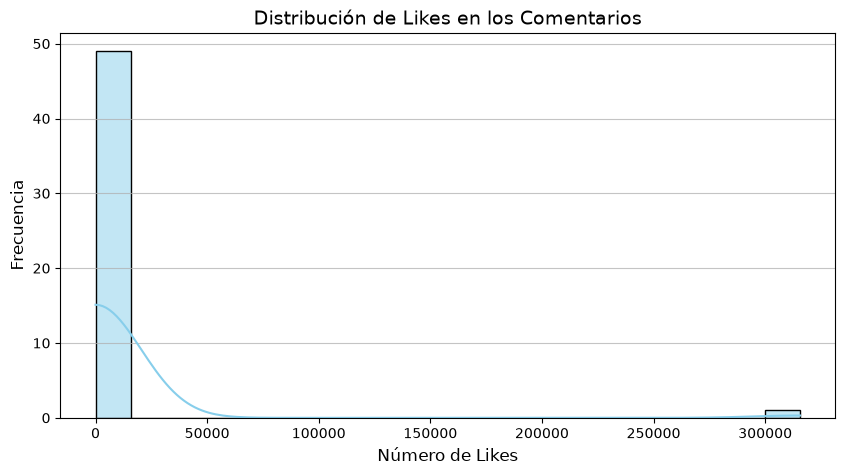

In [4]:
# Visualizaciones legibles, con título y etiquetas
plt.figure(figsize=(10, 5))
sns.histplot(df_comments['likes_comentario'], bins=20, kde=True, color='skyblue')
plt.title('Distribución de Likes en los Comentarios', fontsize=14)
plt.xlabel('Número de Likes', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

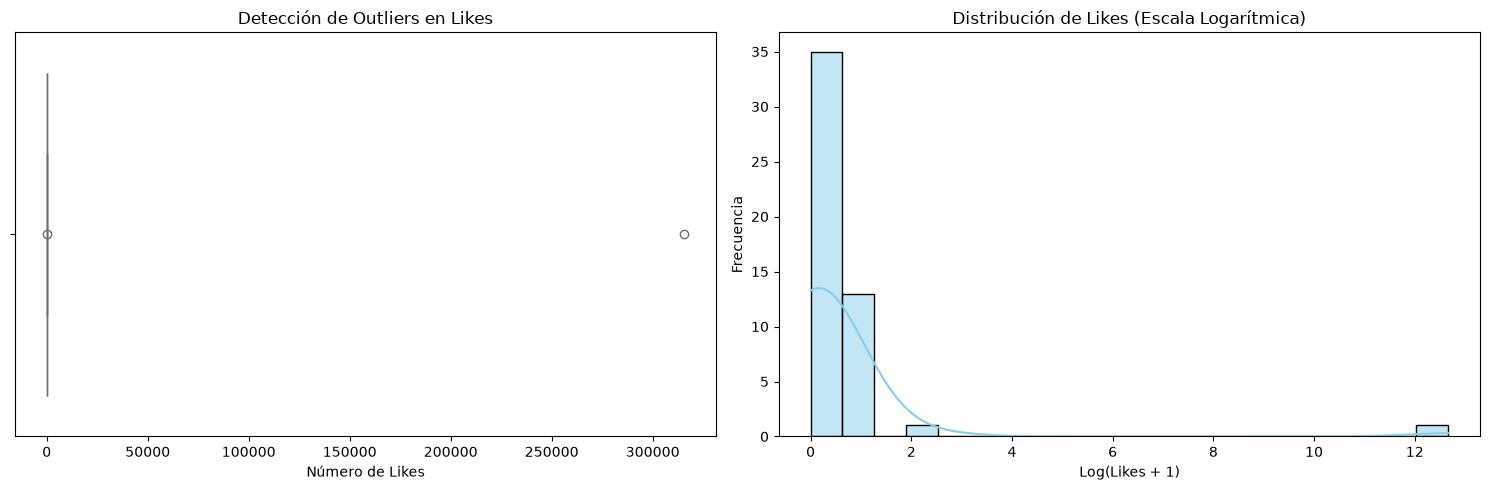

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Crear una figura con dos gráficas
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfica 1: Boxplot para ver el outlier masivo
sns.boxplot(x=df_comments['likes_comentario'], color='lightcoral', ax=axes[0])
axes[0].set_title('Detección de Outliers en Likes', fontsize=12)
axes[0].set_xlabel('Número de Likes')

# Gráfica 2: Histograma con escala logarítmica para ver la distribución real
# Usamos log1p (logaritmo de x + 1) porque tenemos valores en 0
sns.histplot(np.log1p(df_comments['likes_comentario']), bins=20, kde=True, color='skyblue', ax=axes[1])
axes[1].set_title('Distribución de Likes (Escala Logarítmica)', fontsize=12)
axes[1].set_xlabel('Log(Likes + 1)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

## Riesgos y Conclusiones del EDA

### Riesgos para el modelado
* **Sesgo de selección:** Si la muestra se extrae únicamente de videos que ya son virales (como el que tiene un comentario de 315,000 likes), el modelo estará sesgado hacia el éxito y no sabrá predecir el comportamiento de un video con rendimiento promedio o bajo. 
* **Fuga de información (Data Leakage):** Existe un alto riesgo si no controlamos el *timestamp* de extracción. Utilizar el conteo de comentarios o vistas del "Día 5" para predecir las métricas del "Día 2" invalidaría el modelo. Todas las métricas predictivas deben pertenecer estrictamente al momento $t_0$.

### Conclusiones para la Preparación de Datos
1. **Tratamiento del texto:** El texto de los comentarios requiere un preprocesamiento exhaustivo (eliminación de caracteres especiales, emojis y URLs) antes de la extracción de *features* de NLP.
2. **Manejo de Outliers:** Las variables de interacción (`likes_comentario`) presentan asimetría severa. Será obligatorio aplicar transformaciones logarítmicas o escalados robustos (`RobustScaler`) para evitar que los valores atípicos dominen el modelo.
3. **Limpieza básica:** Se procederá a eliminar los registros duplicados identificados en la tabla de comentarios.